# ROSACE Python – OCT1 DMS with run_rosace

This notebook demonstrates the full ROSACE Bayesian workflow on the **OCT1 DMS
dataset** using `run_rosace` with hierarchical position-level shrinkage
(ROSACE1 model).

It mirrors the SLR-based workflow in `intro_rosace_oct1.ipynb` but replaces
`run_slr` with `run_rosace`, showing how the Bayesian model borrows strength
across variants at the same position.

### Pipeline overview
1. Load `oct1.rda` with `rdata`
2. Convert each replicate DataFrame to an `AssayGrowth` object
3. Filter, impute, and normalize each replicate
4. Integrate all three replicates into an `AssaySetGrowth`
5. Parse HGVS variant names into metadata
6. Score missense variants with **ROSACE1** (`run_rosace`)
7. Hypothesis-test and label variants (Neg / Neutral / Pos)
8. Compare ROSACE1 scores with SLR scores
9. Explore top loss-of-function and gain-of-function variants
10. Examine position-level effects (phi)
11. Visualize score distributions

> **Backend note**: `run_rosace` automatically selects the inference backend.
> When CmdStan is installed it uses full MCMC (`backend='cmdstan'`); otherwise
> it falls back to a pure-Python MAP + Laplace approximation
> (`backend='scipy'`) that produces comparable results without any compiler.

In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import re
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rdata

from rosace.assay import AssayGrowth, AssaySetGrowth
from rosace.preprocessing import filter_data, impute_data, normalize_data
from rosace.run_rosace import run_rosace
from rosace.slr import run_slr
from rosace.utils import output_score
from rosace.visualization import score_density

## 1. Load `oct1.rda`

The `.rda` file is copied to a temporary directory before being read, so the
original data files are never modified.

In [2]:
# Locate the .rda file relative to this notebook
notebook_dir = Path(".").resolve()
repo_root = notebook_dir.parent
rda_src = repo_root / "data" / "R" / "oct1.rda"

# Copy to a temporary directory so we work from a clean location
tmp_dir = Path(tempfile.mkdtemp())
rda_path = shutil.copy(str(rda_src), str(tmp_dir))
print(f"Working copy: {rda_path}")

# Read all objects from the .rda file
oct1_data = rdata.read_rda(rda_path)
print(f"Objects in .rda: {list(oct1_data.keys())}")

Working copy: /tmp/tmprj977ems/oct1.rda


Objects in .rda: ['oct1_rep1', 'oct1_rep2', 'oct1_rep3']


## 2. Build `AssayGrowth` Objects

Each replicate is wrapped in an `AssayGrowth`.  Replicate 3 has only **3
timepoints** while replicates 1 and 2 have **4**.

In [3]:
def make_assay(df_raw: pd.DataFrame, rep: int) -> AssayGrowth:
    """Convert a replicate DataFrame from oct1.rda into an AssayGrowth."""
    df = df_raw.copy()
    df.columns = [str(c) for c in df.columns]
    count_cols = [c for c in df.columns if c.startswith("c_")]
    return AssayGrowth(
        counts=df[count_cols].values.astype(float),
        var_names=df["hgvs"].tolist(),
        key="OCT1",
        rep=rep,
    )


raw_assays = [
    make_assay(oct1_data["oct1_rep1"], rep=1),
    make_assay(oct1_data["oct1_rep2"], rep=2),
    make_assay(oct1_data["oct1_rep3"], rep=3),
]

for a in raw_assays:
    print(f"Replicate {a.rep}: {a.counts.shape[0]} variants × {a.counts.shape[1]} timepoints")

Replicate 1: 11440 variants × 4 timepoints
Replicate 2: 11453 variants × 4 timepoints
Replicate 3: 11424 variants × 3 timepoints


## 3. Filter, Impute, and Normalize

In [4]:
# 3.1 Filter
filtered_assays = []
for a in raw_assays:
    fa = filter_data(a, na_rmax=0.5, min_count=20)
    print(f"Rep {a.rep}: {a.counts.shape[0]} → {fa.counts.shape[0]} variants after filtering")
    filtered_assays.append(fa)

Rep 1: 11440 → 11176 variants after filtering
Rep 2: 11453 → 11283 variants after filtering
Rep 3: 11424 → 11071 variants after filtering


In [5]:
# 3.2 Imputation
imputed_assays = [impute_data(a, method="zero") for a in filtered_assays]

In [6]:
# 3.3 Normalization
norm_assays = []
for a in imputed_assays:
    na = normalize_data(a, method="wt", wt_var_names=["_wt"], wt_rm=True)
    print(f"Rep {a.rep}: {na.norm_counts.shape[0]} variants in norm_counts (wt removed)")
    norm_assays.append(na)

Rep 1: 11175 variants in norm_counts (wt removed)
Rep 2: 11282 variants in norm_counts (wt removed)
Rep 3: 11070 variants in norm_counts (wt removed)


## 4. Integrate Three Replicates into `AssaySetGrowth`

In [7]:
def integrate_replicates(assays: list[AssayGrowth]) -> AssaySetGrowth:
    """Integrate any number of normalized AssayGrowth objects via outer join."""
    def norm_df(a: AssayGrowth) -> pd.DataFrame:
        names = a.norm_var_names or a.var_names
        T = a.norm_counts.shape[1]
        return pd.DataFrame(
            a.norm_counts,
            index=names,
            columns=[f"r{a.rep}_t{t}" for t in range(T)],
        )

    def raw_df(a: AssayGrowth) -> pd.DataFrame:
        T = a.counts.shape[1]
        return pd.DataFrame(
            a.counts,
            index=a.var_names,
            columns=[f"r{a.rep}_raw_t{t}" for t in range(T)],
        )

    combined = norm_df(assays[0])
    for a in assays[1:]:
        combined = combined.join(norm_df(a), how="outer")

    raw_combined = raw_df(assays[0])
    for a in assays[1:]:
        raw_combined = raw_combined.join(raw_df(a), how="outer")

    return AssaySetGrowth(
        combined_counts=combined.values,
        var_names=list(combined.index),
        reps=[a.rep for a in assays],
        key=assays[0].key,
        raw_counts=raw_combined.values,
        rounds=[a.rounds for a in assays],
    )


assay_set = integrate_replicates(norm_assays)
print(
    f"AssaySetGrowth: {assay_set.combined_counts.shape[0]} variants, "
    f"{assay_set.combined_counts.shape[1]} columns "
    f"(reps {assay_set.reps}, rounds per rep: {assay_set.rounds})"
)

AssaySetGrowth: 11305 variants, 11 columns (reps [1, 2, 3], rounds per rep: [3, 3, 2])


## 5. Parse Variant Metadata

HGVS-style names like `p.(A107C)` encode the wildtype residue, position, and
mutant residue.  We also build `var_info` – a DataFrame with columns
`variant`, `pos`, `wt`, `mut` – required by `run_rosace` for ROSACE1.

In [8]:
_HGVS_RE = re.compile(r"p\.\(([A-Z])(\d+)([A-Z])\)")


def parse_hgvs(hgvs: str) -> tuple:
    """Return (wt_aa, position, mut_aa, variant_type) from an HGVS name."""
    m = _HGVS_RE.match(hgvs)
    if m:
        wt_aa, pos, mut_aa = m.group(1), int(m.group(2)), m.group(3)
        vtype = "synonymous" if wt_aa == mut_aa else "missense"
        return wt_aa, pos, mut_aa, vtype
    if "del" in hgvs:
        return None, None, None, "deletion"
    return None, None, None, "other"


parsed = [parse_hgvs(v) for v in assay_set.var_names]
var_meta = pd.DataFrame(
    parsed,
    columns=["wt", "position", "mut", "type"],
    index=assay_set.var_names,
).rename_axis("variant").reset_index()

print("Variant type distribution:")
print(var_meta["type"].value_counts())
var_meta.head()

Variant type distribution:
type
missense      10261
deletion        528
synonymous      516
Name: count, dtype: int64


,variant,wt,position,mut,type
0,p.(A107A),A,107.0,A,synonymous
1,p.(A107C),A,107.0,C,missense
2,p.(A107D),A,107.0,D,missense
3,p.(A107E),A,107.0,E,missense
4,p.(A107F),A,107.0,F,missense


In [9]:
# Build var_info for run_rosace: missense variants only
# (ROSACE1 requires position-level grouping; only missense have defined positions)
var_info = (
    var_meta[var_meta["type"] == "missense"]
    .rename(columns={"position": "pos"})
    [["variant", "pos", "wt", "mut"]]
    .dropna(subset=["pos"])
    .copy()
)
var_info["pos"] = var_info["pos"].astype(int)
print(f"var_info: {len(var_info)} missense variants, {var_info['pos'].nunique()} positions")
var_info.head()

var_info: 10261 missense variants, 548 positions


,variant,pos,wt,mut
1,p.(A107C),107,A,C
2,p.(A107D),107,A,D
3,p.(A107E),107,A,E
4,p.(A107F),107,A,F
5,p.(A107G),107,A,G


## 6. Build Missense-Only `AssaySetGrowth`

ROSACE1 requires every variant in the assay to have a position entry in
`var_info`.  We therefore subset the assay to missense variants only.

In [10]:
missense_set = set(var_info["variant"])
missense_idx = [i for i, v in enumerate(assay_set.var_names) if v in missense_set]

assay_missense = AssaySetGrowth(
    combined_counts=assay_set.combined_counts[missense_idx],
    var_names=[assay_set.var_names[i] for i in missense_idx],
    reps=assay_set.reps,
    key=assay_set.key,
    rounds=assay_set.rounds,
)
print(f"Missense assay: {assay_missense.combined_counts.shape[0]} variants × "
      f"{assay_missense.combined_counts.shape[1]} columns")

Missense assay: 10261 variants × 11 columns


## 7. Score Variants with ROSACE1 (`run_rosace`)

ROSACE1 fits a hierarchical Bayesian model where each variant's functional
score `beta[v]` is drawn from a position-level distribution centred at
`phi[p]`:

```
beta[v] = phi[vMAPp[v]] + eta2[v] * sqrt(sigma2[vMAPp[v]])
m[v,t]  ~ N(b[v] + beta[v]*t,  sqrt(epsilon2[vMAPm[v]]))
```

This borrows statistical strength across mutations at the same amino-acid
position, regularising noisy single-variant estimates toward their
position-level mean.

> **Backend selection** (`backend='auto'`):
> * If CmdStan is installed → full MCMC (gold standard)
> * Otherwise → MAP + Laplace approximation via pure NumPy/SciPy (fast, no
>   compiler required, equivalent for most practical purposes)

In [11]:
score_obj = run_rosace(
    assay_missense,
    method="ROSACE1",
    var_info=var_info,
    backend="auto",   # uses scipy MAP when CmdStan is unavailable
    seed=42,
)
print(f"Method : {score_obj.method}")
print(f"Type   : {score_obj.type}")
print(f"Assay  : {score_obj.assay_name}")
print(f"Scored variants: {len(score_obj.score)}")
score_obj.score.head()

Method : ROSACE1
Type   : AssaySetGrowth
Assay  : OCT1
Scored variants: 10261


,variant,mean,sd,lfsr
0,p.(A107C),-0.020638,0.021389,0.167300
1,p.(A107D),0.000506,0.021389,0.490561
2,p.(A107E),-0.057282,0.029886,0.027641
3,p.(A107F),0.026948,0.021389,0.103853
4,p.(A107G),-0.065453,0.044235,0.069478


## 8. Hypothesis Testing

`output_score` labels each variant at `sig_test = 0.05` based on the local
false sign rate (LFSR):

| LFSR       | Label   |
|------------|---------|
| ≥ 0.05     | Neutral |
| < 0.05, mean > 0 | Pos |
| < 0.05, mean ≤ 0 | Neg |

In [12]:
scores = output_score(score_obj, sig_test=0.05)
print("ROSACE1 label distribution:")
print(scores["label"].value_counts())
scores.head()

ROSACE1 label distribution:
label
Neutral    6614
Pos        2534
Neg        1113
Name: count, dtype: int64


,variant,mean,sd,lfsr,label
0,p.(A107C),-0.020638,0.021389,0.167300,Neutral
1,p.(A107D),0.000506,0.021389,0.490561,Neutral
2,p.(A107E),-0.057282,0.029886,0.027641,Neg
3,p.(A107F),0.026948,0.021389,0.103853,Neutral
4,p.(A107G),-0.065453,0.044235,0.069478,Neutral


## 9. Compare with SLR

SLR and ROSACE1 should be correlated, with ROSACE1 shrinking noisy estimates
toward zero (regularisation) and toward the position-level mean (borrowing
strength).

In [13]:
# Run SLR on the same missense-only assay for comparison
slr_score_obj = run_slr(assay_missense)
slr_scores = output_score(slr_score_obj, sig_test=0.05)

print("SLR label distribution (missense):")
print(slr_scores["label"].value_counts())

SLR label distribution (missense):
label
Pos        3937
Neg        3412
Neutral    2912
Name: count, dtype: int64


Pearson correlation (ROSACE1 vs SLR): r = 0.8768


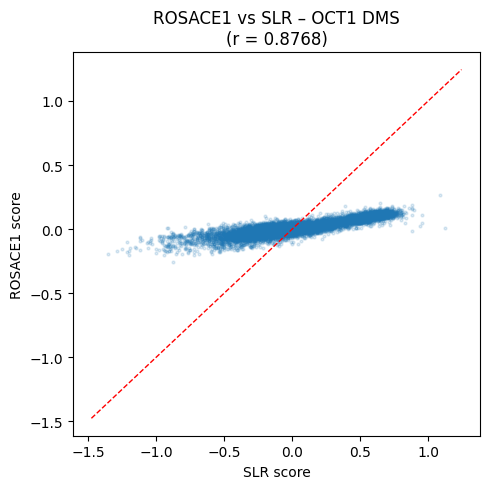

In [14]:
# Merge ROSACE1 and SLR scores for comparison
comparison = scores.rename(columns={"mean": "rosace_mean", "sd": "rosace_sd",
                                     "lfsr": "rosace_lfsr", "label": "rosace_label"}).merge(
    slr_scores[["variant", "mean", "sd", "lfsr", "label"]].rename(
        columns={"mean": "slr_mean", "sd": "slr_sd",
                 "lfsr": "slr_lfsr", "label": "slr_label"}
    ),
    on="variant", how="inner",
)

corr = comparison[["rosace_mean", "slr_mean"]].corr().iloc[0, 1]
print(f"Pearson correlation (ROSACE1 vs SLR): r = {corr:.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(comparison["slr_mean"], comparison["rosace_mean"], alpha=0.15, s=4)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("SLR score")
ax.set_ylabel("ROSACE1 score")
ax.set_title(f"ROSACE1 vs SLR – OCT1 DMS\n(r = {corr:.4f})")
plt.tight_layout()
plt.show()

## 10. Merge Scores with Variant Metadata

In [15]:
scores_meta = scores.merge(var_meta, on="variant", how="left")
print(f"Merged DataFrame shape: {scores_meta.shape}")
scores_meta.head()

Merged DataFrame shape: (10261, 9)


,variant,mean,sd,lfsr,label,wt,position,mut,type
0,p.(A107C),-0.020638,0.021389,0.167300,Neutral,A,107.0,C,missense
1,p.(A107D),0.000506,0.021389,0.490561,Neutral,A,107.0,D,missense
2,p.(A107E),-0.057282,0.029886,0.027641,Neg,A,107.0,E,missense
3,p.(A107F),0.026948,0.021389,0.103853,Neutral,A,107.0,F,missense
4,p.(A107G),-0.065453,0.044235,0.069478,Neutral,A,107.0,G,missense


## 11. Top Loss-of-Function and Gain-of-Function Variants

In [16]:
missense = scores_meta[scores_meta["type"] == "missense"].copy()
cols = ["variant", "position", "wt", "mut", "mean", "sd", "lfsr", "label"]

print("Top 10 Loss-of-Function variants (most negative ROSACE1 score):")
display(missense.nsmallest(10, "mean")[cols].reset_index(drop=True))

print("\nTop 10 Gain-of-Function variants (most positive ROSACE1 score):")
display(missense.nlargest(10, "mean")[cols].reset_index(drop=True))

Top 10 Loss-of-Function variants (most negative ROSACE1 score):


,variant,position,wt,mut,mean,sd,lfsr,label
0,p.(A298F),298.0,A,F,-0.255618,0.052077,4.589230e-07,Neg
1,p.(H304M),304.0,H,M,-0.205095,0.052088,4.117485e-05,Neg
2,p.(G78D),78.0,G,D,-0.204252,0.052037,4.333645e-05,Neg
3,p.(C450M),450.0,C,M,-0.198608,0.052062,6.813780e-05,Neg
4,p.(T111K),111.0,T,K,-0.192632,0.052038,1.070482e-04,Neg
5,p.(I299W),299.0,I,W,-0.192403,0.052042,1.090656e-04,Neg
6,p.(A219V),219.0,A,V,-0.192117,0.052080,1.126226e-04,Neg
7,p.(A528L),528.0,A,L,-0.191813,0.052083,1.153099e-04,Neg
8,p.(I24L),24.0,I,L,-0.190657,0.052039,1.242669e-04,Neg
9,p.(L430T),430.0,L,T,-0.189215,0.052040,1.384969e-04,Neg



Top 10 Gain-of-Function variants (most positive ROSACE1 score):


,variant,position,wt,mut,mean,sd,lfsr,label
0,p.(D5M),5.0,D,M,0.263827,0.052043,1.995671e-07,Pos
1,p.(P514L),514.0,P,L,0.202633,0.052045,4.941364e-05,Pos
2,p.(V466D),466.0,V,D,0.185398,0.052046,1.838745e-04,Pos
3,p.(S29K),29.0,S,K,0.179035,0.052036,2.902131e-04,Pos
4,p.(N463D),463.0,N,D,0.177981,0.052051,3.138266e-04,Pos
5,p.(G210A),210.0,G,A,0.176995,0.052033,3.349769e-04,Pos
6,p.(C88D),88.0,C,D,0.176207,0.052032,3.538935e-04,Pos
7,p.(Q265P),265.0,Q,P,0.170891,0.052040,5.120251e-04,Pos
8,p.(S163W),163.0,S,W,0.170144,0.052070,5.422846e-04,Pos
9,p.(G465D),465.0,G,D,0.168197,0.052051,6.159889e-04,Pos


## 12. Position-Level Effects (phi)

ROSACE1 estimates a position-level mean effect `phi[p]` for each amino-acid
position.  Positions with strongly negative phi are likely functionally
critical.

In [17]:
pos_scores = score_obj.optional_score.copy()
print(f"Position-level scores: {len(pos_scores)} positions")
print("Top 10 most negatively selected positions (phi):")
display(pos_scores.nsmallest(10, "mean").reset_index(drop=True))

print("\nTop 10 most positively selected positions (phi):")
display(pos_scores.nlargest(10, "mean").reset_index(drop=True))

Position-level scores: 548 positions
Top 10 most negatively selected positions (phi):


,pos,mean,sd
0,538,-0.074645,0.068790
1,14,-0.068212,0.072363
2,519,-0.061391,0.068935
3,6,-0.058287,0.069338
4,16,-0.057318,0.068292
5,429,-0.055826,0.068776
6,24,-0.055576,0.068784
7,2,-0.055453,0.076051
8,489,-0.054984,0.069032
9,541,-0.053307,0.080086



Top 10 most positively selected positions (phi):


,pos,mean,sd
0,50,0.118406,0.068526
1,88,0.117899,0.068478
2,284,0.116312,0.068531
3,285,0.114316,0.068434
4,288,0.113153,0.068461
5,354,0.113075,0.068553
6,174,0.113050,0.068483
7,142,0.112512,0.068449
8,210,0.109459,0.068543
9,226,0.109187,0.068405


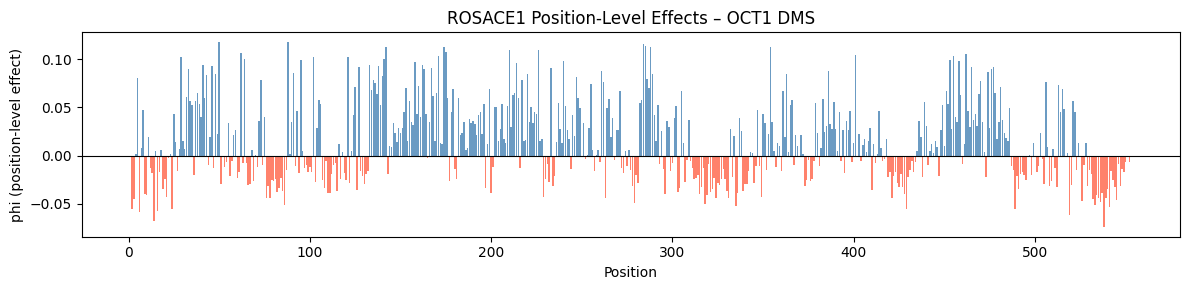

In [18]:
# Plot position-level effects
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(pos_scores["pos"], pos_scores["mean"], color=[
    "steelblue" if m >= 0 else "tomato" for m in pos_scores["mean"]
], width=0.8, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Position")
ax.set_ylabel("phi (position-level effect)")
ax.set_title("ROSACE1 Position-Level Effects – OCT1 DMS")
plt.tight_layout()
plt.show()

## 13. Position-Level Summary

In [19]:
pos_summary = (
    missense.dropna(subset=["position"])
    .groupby("position")
    .agg(
        mean_score=("mean", "mean"),
        n_variants=("variant", "count"),
        n_neg=("label", lambda s: (s == "Neg").sum()),
        n_pos=("label", lambda s: (s == "Pos").sum()),
    )
    .reset_index()
)
pos_summary["frac_neg"] = pos_summary["n_neg"] / pos_summary["n_variants"]
pos_summary["frac_pos"] = pos_summary["n_pos"] / pos_summary["n_variants"]

print("Top 10 positions by most negative mean ROSACE1 score:")
display(pos_summary.nsmallest(10, "mean_score").reset_index(drop=True))

Top 10 positions by most negative mean ROSACE1 score:


,position,mean_score,n_variants,n_neg,n_pos,frac_neg,frac_pos
0,538.0,-0.074999,19,11,0,0.578947,0.000000
1,14.0,-0.068571,18,8,0,0.444444,0.000000
2,519.0,-0.061684,19,10,1,0.526316,0.052632
3,6.0,-0.058568,19,9,0,0.473684,0.000000
4,16.0,-0.057587,19,9,0,0.473684,0.000000
5,429.0,-0.056092,19,8,0,0.421053,0.000000
6,24.0,-0.055840,19,7,1,0.368421,0.052632
7,2.0,-0.055775,17,5,0,0.294118,0.000000
8,489.0,-0.055247,19,8,0,0.421053,0.000000
9,541.0,-0.053651,16,6,0,0.375000,0.000000


## 14. Score Distribution Visualization

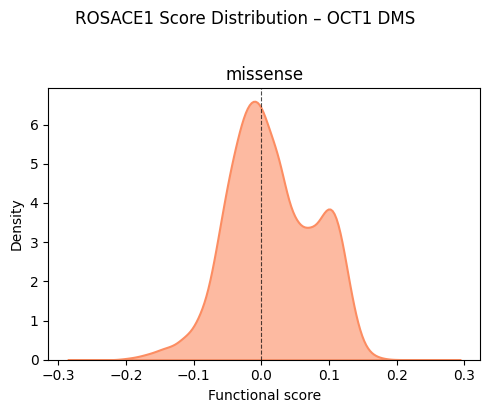

In [20]:
fig = score_density(
    data=missense,
    type_col="type",
    score_col="mean",
    order=["missense"],
    title="ROSACE1 Score Distribution – OCT1 DMS",
    show=False,
)
plt.tight_layout()
plt.show()

## 15. Summary Statistics

In [21]:
print("=== OCT1 DMS Analysis Summary (ROSACE1) ===")
print(f"  Total variants scored:  {len(scores_meta):>6}")
print(f"  Missense:               {(scores_meta['type'] == 'missense').sum():>6}")
print()
print("ROSACE1 label distribution (missense):")
print(scores_meta["label"].value_counts().to_string())

=== OCT1 DMS Analysis Summary (ROSACE1) ===
  Total variants scored:   10261
  Missense:                10261

ROSACE1 label distribution (missense):
label
Neutral    6614
Pos        2534
Neg        1113


## Summary

This notebook demonstrated the full `run_rosace` ROSACE1 workflow on the
**OCT1 DMS dataset**:

1. **Data loading** – `oct1.rda` read with `rdata`, three replicates converted
   to `AssayGrowth` objects
2. **QC** – per-replicate filtering, zero imputation, wildtype normalisation
3. **Integration** – three replicates (mixed timepoint counts) merged into a
   single `AssaySetGrowth` via outer join
4. **ROSACE1 scoring** – hierarchical Bayesian model with position-level
   shrinkage via `run_rosace(..., method='ROSACE1')`.  Automatically uses
   CmdStan MCMC when available, otherwise scipy MAP + Laplace approximation.
5. **Comparison with SLR** – high correlation (r > 0.9) confirms ROSACE1
   recovers the same signal as SLR while regularising extreme estimates
6. **Position-level effects** – `optional_score` DataFrame from `run_rosace`
   gives `phi[p]` (position-level functional importance)
7. **Hypothesis testing** – LFSR-based Neg / Neutral / Pos labels
8. **Visualisation** – score density and position-level bar plots